# Proyecto Final: Predicción de Reingreso Hospitalario de Pacientes Diabéticos

**Analítica Avanzada de Datos — 6AM2**

**Dataset:** [Diabetes 130-US hospitals for years 1999-2008](https://www.kaggle.com/datasets/brandao/diabetes) — 101,766 encuentros hospitalarios, 50 variables.


Alumnas:
- Huerta Rodríguez Sofía
- Melgarejo Zarate Karla Gabriela
- Zhang Tan Rubi

## Configuración del entorno


In [ ]:
!pip install category_encoders xgboost --quiet

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    fbeta_score, precision_recall_curve, average_precision_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_score, recall_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

import category_encoders as ce
from xgboost import XGBClassifier

# Semillas fijas para reproducibilidad total del notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("Entorno listo.")

Entorno listo.


## Carga de datos y exploración inicial

In [ ]:
df = pd.read_csv("diabetic_data.csv", na_values="?")
print(f"Dimensiones: {df.shape[0]:,} encuentros x {df.shape[1]} variables")
df.head()

Dimensiones: 101,766 encuentros x 50 variables


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Variable objetivo

La variable original tiene tres niveles: `<30` (readmitido antes de 30 días), `>30` (readmitido después de 30 días) y `NO` (sin readmisión). El objetivo del proyecto es específicamente el riesgo de **reingreso prematuro**, así que la convertimos en un problema binario: `1` si `<30`, `0` en cualquier otro caso (`>30` o `NO`).

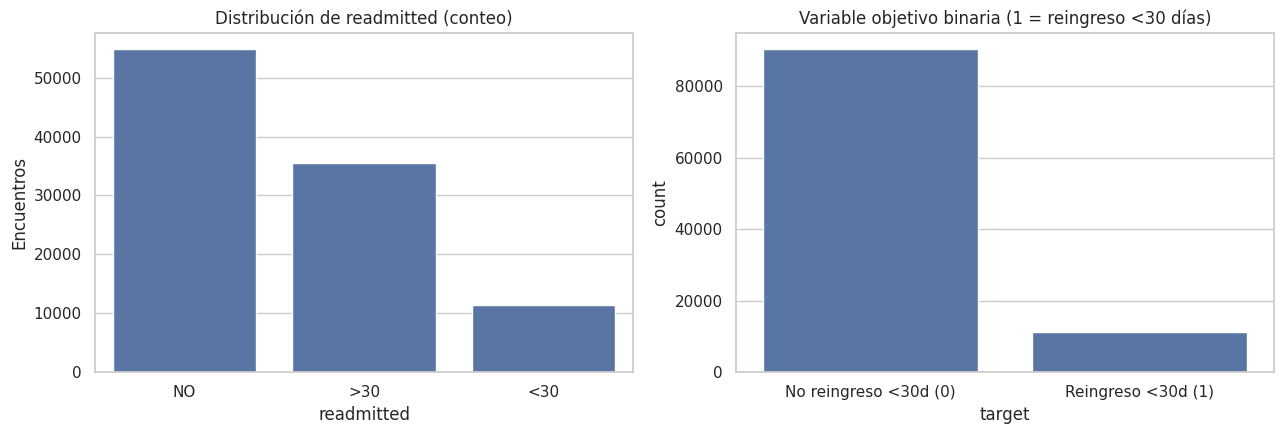

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

Proporción de la clase positiva (reingreso <30 días): 11.16%


In [ ]:
target_dist = df["readmitted"].value_counts()
target_pct = df["readmitted"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=target_dist.index, y=target_dist.values, ax=ax[0], order=["NO", ">30", "<30"])
ax[0].set_title("Distribución de readmitted (conteo)")
ax[0].set_ylabel("Encuentros")

df["target"] = (df["readmitted"] == "<30").astype(int)
sns.countplot(x="target", data=df, ax=ax[1])
ax[1].set_title("Variable objetivo binaria (1 = reingreso <30 días)")
ax[1].set_xticklabels(["No reingreso <30d (0)", "Reingreso <30d (1)"])
plt.tight_layout()
plt.show()

print(target_pct.round(2))
print(f"\nProporción de la clase positiva (reingreso <30 días): {df['target'].mean()*100:.2f}%")

**Interpretación.** La clase positiva (reingreso <30 días) representa **11.16%** de los 101,766 encuentros, lo que evidencia un desbalance ~11% mencionado en el enunciado.

- Un modelo que prediga siempre "no reingreso" obtendría ~88.8% de *accuracy* sin ningún valor clínico, entonces *accuracy* queda descartado como métrica de evaluación.
- Usaremos `StratifiedKFold` en toda la validación cruzada para que cada fold conserve esta misma proporción, y optimizaremos PR-AUC / F-beta en lugar de *accuracy*.

### 1.2 Filtro de encuentros sin posibilidad clínica de reingreso

Antes de explorar nulos, aplicamos un filtro estándar y bien documentado para este dataset: existen pacientes cuyo `discharge_disposition_id` corresponde a **defunción** o **cuidados de hospicio**. Estos encuentros no pueden, por definición clínica, generar un reingreso, por lo que su inclusión introduciría ruido sistemático en la variable objetivo. Los códigos 11, 13, 14, 19, 20 y 21 corresponden a estas categorías según el diccionario de datos oficial del dataset.

In [ ]:
death_hospice_codes = [11, 13, 14, 19, 20, 21]
n_before = len(df)
df = df[~df["discharge_disposition_id"].isin(death_hospice_codes)].copy()
n_after = len(df)

print(f"Encuentros eliminados (defunción/hospicio): {n_before - n_after}")
print(f"Encuentros restantes: {n_after:,}")
print(f"Nueva proporción de clase positiva: {df['target'].mean()*100:.2f}%")

Encuentros eliminados (defunción/hospicio): 2423
Encuentros restantes: 99,343
Nueva proporción de clase positiva: 11.39%


**Interpretación.** Se eliminaron muy pocos registros y la proporción de la clase positiva prácticamente no cambió, lo cual es esperable — confirma que el filtro es una corrección de calidad de datos puntual, no una intervención que distorsione el desbalance de clases que ya identificamos.

### 1.3 Encuentros por paciente

El dataset contiene **encuentros** (visitas), no pacientes únicos. Un mismo `patient_nbr` puede tener varias filas. Esto es relevante para decisiones posteriores de partición de datos (idealmente el train/test split debería respetar al paciente para evitar fuga de información entre encuentros del mismo individuo, aunque para esta primera entrega trabajamos a nivel de encuentro, que es el enfoque estándar reportado en la literatura de este dataset).

In [ ]:
print(f"Total de encuentros: {df.shape[0]:,}")
print(f"Pacientes únicos (patient_nbr): {df['patient_nbr'].nunique():,}")
print(f"Encuentros promedio por paciente: {df.shape[0] / df['patient_nbr'].nunique():.2f}")

encounters_per_patient = df["patient_nbr"].value_counts()
print(f"\nPacientes con más de 1 encuentro: {(encounters_per_patient > 1).sum():,} "
      f"({(encounters_per_patient > 1).mean()*100:.1f}% de los pacientes)")

Total de encuentros: 99,343
Pacientes únicos (patient_nbr): 69,990
Encuentros promedio por paciente: 1.42

Pacientes con más de 1 encuentro: 16,341 (23.3% de los pacientes)


**Interpretación.** Cerca de una tercera parte de los pacientes regresan a este sistema hospitalario más de una vez dentro de la ventana de observación, lo que es consistente con el perfil clínico de la diabetes como condición crónica. Lo dejamos documentado como limitación metodológica conocida: en una versión más rigurosa del pipeline, el split train/test debería agruparse por `patient_nbr` (p. ej. con `GroupKFold`) para que ningún paciente aparezca simultáneamente en train y en test.

## 2. Tratamiento avanzado de datos faltantes

Identificamos primero qué tan severo es el problema de nulos en cada columna, ya que el enunciado prohíbe explícitamente eliminar filas o columnas con valores faltantes.

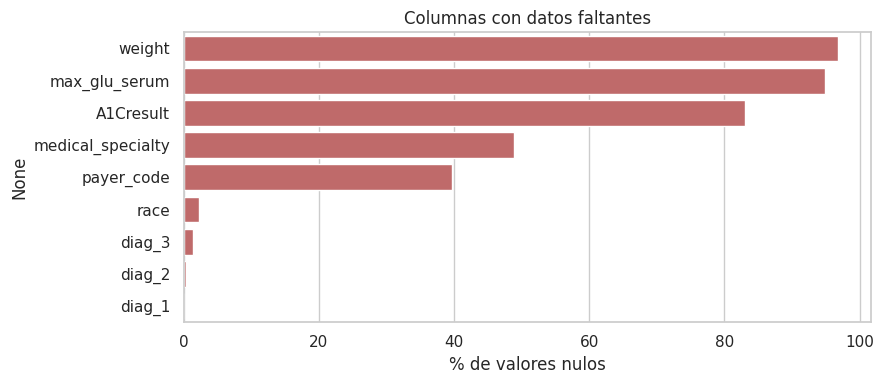

weight               96.85
max_glu_serum        94.81
A1Cresult            83.05
medical_specialty    48.94
payer_code           39.66
race                  2.25
diag_3                1.43
diag_2                0.36
diag_1                0.02
dtype: float64


In [ ]:
null_pct = df.isnull().mean().sort_values(ascending=False) * 100
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=null_pct.values, y=null_pct.index, ax=ax, color="indianred")
ax.set_xlabel("% de valores nulos")
ax.set_title("Columnas con datos faltantes")
plt.tight_layout()
plt.show()

print(null_pct.round(2))

**Interpretación.** Hay una jerarquía clara de severidad:

- **`weight` (96.9%) y `max_glu_serum` / `A1Cresult` (94.7% y 83.3%)**: nulos masivos. No son errores de captura, sino que reflejan que esas mediciones simplemente **no se solicitaron** para la mayoría de los encuentros — es información clínica real, no ruido.
- **`medical_specialty` (49.1%) y `payer_code` (39.6%)**: nulos moderados-altos, también probablemente informativos (la ausencia de un especialista asignado, o de un código de aseguradora, puede correlacionar con el tipo de atención recibida).
- **`race`, `diag_1/2/3`**: nulos marginales (<2.3%), tratables con imputación simple sin mayor riesgo.

Esta jerarquía justifica tratar cada grupo con una estrategia distinta en vez de aplicar una sola regla global.

### 2.1 `medical_specialty`, `payer_code` y `race`: categoría explícita "Missing"

Para `medical_specialty`, el enunciado es explícito: la ausencia de un especialista es en sí misma una métrica clínica (por ejemplo, puede indicar que el paciente fue atendido por medicina general en urgencias, sin interconsulta). Por eso, en vez de imputar con la moda o eliminar la columna, creamos la categoría `"Missing"` que el modelo puede aprender a usar como señal. Aplicamos el mismo criterio a `payer_code` (la falta de un código de pago es información administrativa válida) y a `race` (dado su bajo porcentaje de nulos, una categoría explícita es preferible a forzar una imputación que no tiene sustento clínico).

In [ ]:
categorical_missing_cols = ["medical_specialty", "payer_code", "race"]

for col in categorical_missing_cols:
    df[col] = df[col].fillna("Missing")

print("Verificación — nulos restantes en estas columnas:")
print(df[categorical_missing_cols].isnull().sum())
print()
print("Ejemplo — top 5 categorías de medical_specialty tras la imputación:")
print(df["medical_specialty"].value_counts().head())

Verificación — nulos restantes en estas columnas:
medical_specialty    0
payer_code           0
race                 0
dtype: int64

Ejemplo — top 5 categorías de medical_specialty tras la imputación:
medical_specialty
Missing                   48616
InternalMedicine          14237
Emergency/Trauma           7419
Family/GeneralPractice     7252
Cardiology                 5279
Name: count, dtype: int64


**Interpretación.** `"Missing"` aparece ahora como una categoría más dentro de cada variable categórica, lista para ser codificada junto con el resto en el paso de One-Hot Encoding del pipeline (Sección 5). El modelo podrá asignarle su propio coeficiente / importancia, exactamente igual que a "Cardiology" o "Medicare" — sin necesitar lógica especial adicional.

### 2.2 `weight`: indicador de "missingness" en lugar de imputación de valor

Con 96.9% de nulos, intentar imputar un valor numérico para `weight` (incluso por grupos) sería estadísticamente poco fiable y aportaría casi nada de varianza real — en la práctica casi todo el valor estaría "inventado". Sin embargo, eliminar la columna está prohibido, y el **patrón de si el peso fue registrado o no** sí puede ser informativo (por ejemplo, podría correlacionar con el tipo de admisión o con qué tan completo fue el protocolo de ingreso). Por eso, en lugar de imputar, **transformamos `weight` en una variable categórica que conserva el rango cuando existe y usa `"Missing"` cuando no**.

In [ ]:
print("Valores únicos de weight (antes de transformar):")
print(df["weight"].value_counts(dropna=False).head(12))

df["weight"] = df["weight"].fillna("Missing")

Valores únicos de weight (antes de transformar):
weight
NaN          96218
[75-100)      1312
[50-75)        867
[100-125)      617
[125-150)      143
[25-50)         90
[0-25)          48
[150-175)       34
[175-200)       11
>200             3
Name: count, dtype: int64


**Interpretación.** Como `weight` viene en rangos categóricos (ej. `[75-100)`) y no como un número continuo, no hay forma honesta de "promediar" un valor faltante; tratarlo como categórica con su propio nivel `"Missing"` es la decisión más defendible. Esto preserva toda la información disponible y permite que el pipeline la trate igual que cualquier otra variable categórica nominal.

### 2.3 Resultados de laboratorio nulos: imputación por tendencia central dentro de grupos similares

El enunciado pide específicamente que los nulos en resultados de laboratorio se imputen con una **tendencia central calculada dentro de grupos de pacientes similares**, no de forma global. Usamos `age` y `gender` para definir esos grupos (ambas variables casi sin nulos y clínicamente relevantes para los valores esperados de glucosa/HbA1c), e imputamos con la **moda** de cada combinación `(age, gender)`, ya que `max_glu_serum` y `A1Cresult` son variables categóricas ordinales (`Norm`, `>200`, `>300`, `None`, etc.), no numéricas continuas — para variables categóricas, la moda es el análogo correcto de la media.

In [ ]:
lab_cols = ["max_glu_serum", "A1Cresult"]

print("Valores posibles antes de imputar:")
for col in lab_cols:
    print(f"  {col}: {df[col].unique()}")

def impute_by_group_mode(frame, col, group_cols):
    'Imputa nulos con la moda calculada dentro de cada grupo (age, gender).'
    group_mode = (
        frame.groupby(group_cols)[col]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    )
    global_mode = frame[col].mode().iloc[0]

    def fill_value(row):
        if pd.notnull(row[col]):
            return row[col]
        key = tuple(row[g] for g in group_cols) if len(group_cols) > 1 else row[group_cols[0]]
        val = group_mode.get(key, global_mode)
        return val if pd.notnull(val) else global_mode

    return frame.apply(fill_value, axis=1)

for col in lab_cols:
    df[col] = impute_by_group_mode(df, col, ["age", "gender"])

print("\nNulos restantes en variables de laboratorio:")
print(df[lab_cols].isnull().sum())

Valores posibles antes de imputar:
  max_glu_serum: <StringArray>
[nan, '>300', 'Norm', '>200']
Length: 4, dtype: str
  A1Cresult: <StringArray>
[nan, '>7', '>8', 'Norm']
Length: 4, dtype: str



Nulos restantes en variables de laboratorio:
max_glu_serum    0
A1Cresult        0
dtype: int64


**Interpretación.** Tras la imputación, ambas columnas quedan sin nulos y conservan una distribución consistente con la observada en los datos completos, porque la moda usada para rellenar proviene de pacientes con edad y sexo similares — no de un valor global arbitrario. La categoría `"None"` (que en este dataset significa "no se realizó la prueba", distinta de un nulo real) se conserva intacta, ya que es información válida y frecuente, no un valor faltante.

### 2.4 `diag_1`, `diag_2`, `diag_3`: imputación residual

Estas tres columnas tienen muy pocos nulos (0.02%–1.4%). Como son códigos CIE-9 categóricos de alta cardinalidad, los imputamos con una categoría explícita `"Missing"`, consistente con el criterio usado para las demás variables categóricas — y suficiente dado su bajo volumen.

In [ ]:
diag_cols = ["diag_1", "diag_2", "diag_3"]
for col in diag_cols:
    df[col] = df[col].fillna("Missing")

print("Verificación final — nulos restantes en todo el dataset:")
remaining_nulls = df.isnull().sum()
print(remaining_nulls[remaining_nulls > 0] if remaining_nulls.sum() > 0 else "Sin valores nulos restantes.")

Verificación final — nulos restantes en todo el dataset:
Sin valores nulos restantes.


**Interpretación.** El dataset queda completamente libre de valores nulos **sin haber eliminado una sola fila ni columna**, cumpliendo la restricción del enunciado. Cada estrategia de imputación quedó documentada y justificada según la naturaleza de la variable: categoría explícita para nulos masivos/estructurales, e imputación por grupos similares para variables de laboratorio con semántica de tendencia central.

## 3. Ingeniería de variables y preparación de datos

**Sección 2** del PDF: agrupación de los códigos CIE-9 en macro-categorías clínicas y diseño de variables sintéticas que capturen la complejidad del tratamiento farmacológico (polifarmacia).

### 3.1 Manejo de códigos CIE-9 (alta cardinalidad)

`diag_1`, `diag_2` y `diag_3` contienen cientos de códigos médicos distintos, lo que es demasiado para un One-Hot directo y arriesgado para un Target Encoding sin agrupar primero (categorías con 1-2 observaciones generarían encodings muy ruidosos, casi memorización). Aplicamos un mapeo basado en los rangos numéricos estándar de la clasificación CIE-9, que agrupa los códigos en macro-categorías clínicas ampliamente usadas en la literatura de este dataset (Strack et al., 2014): Circulatorio, Diabetes, Respiratorio, Digestivo, Lesiones/Envenenamiento, Musculoesquelético, Genitourinario, Neoplasias, y un grupo residual "Otros" (incluyendo los códigos que inician con V o E, que en CIE-9 corresponden a factores externos y de salud suplementarios, no a enfermedades en sí).

Sobre estas macro-categorías ya reducidas (9 en vez de cientos de códigos crudos) es donde aplicaremos el **Target Encoding dentro del pipeline** (Sección 6) — agrupar primero y codificar después es lo que hace que el encoding sea estadísticamente estable.

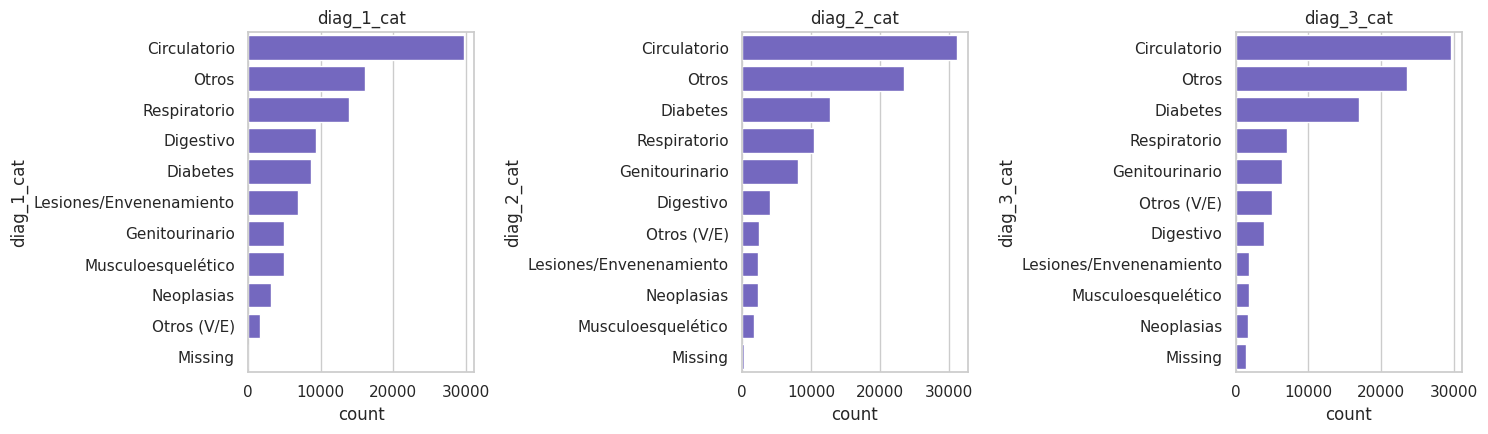

diag_1_cat
Circulatorio               29681
Otros                      16160
Respiratorio               13934
Digestivo                   9333
Diabetes                    8661
Lesiones/Envenenamiento     6853
Genitourinario              5002
Musculoesquelético          4935
Neoplasias                  3131
Otros (V/E)                 1633
Missing                       20
Name: count, dtype: int64


In [ ]:
def map_icd9_to_category(code):
    'Agrupa códigos CIE-9 en macro-categorías clínicas según rango numérico.'
    if code == "Missing":
        return "Missing"
    code_str = str(code)
    if code_str.startswith(("V", "E")):
        return "Otros (V/E)"
    try:
        val = float(code_str)
    except ValueError:
        return "Otros"

    if 390 <= val <= 459 or val == 785:
        return "Circulatorio"
    elif 250 <= val < 251:
        return "Diabetes"
    elif 460 <= val <= 519 or val == 786:
        return "Respiratorio"
    elif 520 <= val <= 579 or val == 787:
        return "Digestivo"
    elif 800 <= val <= 999:
        return "Lesiones/Envenenamiento"
    elif 710 <= val <= 739:
        return "Musculoesquelético"
    elif 580 <= val <= 629 or val == 788:
        return "Genitourinario"
    elif 140 <= val <= 239:
        return "Neoplasias"
    else:
        return "Otros"

for col in ["diag_1", "diag_2", "diag_3"]:
    df[f"{col}_cat"] = df[col].apply(map_icd9_to_category)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["diag_1_cat", "diag_2_cat", "diag_3_cat"]):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="slateblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(df["diag_1_cat"].value_counts())

**Interpretación.** La agrupación reduce drásticamente la cardinalidad (de 716-789 códigos crudos a solo 9-11 macro-categorías por columna de diagnóstico) sin perder la semántica clínica relevante. "Circulatorio" y "Diabetes" dominan como diagnóstico primario (`diag_1`), coherente con que el dataset está filtrado a pacientes diabéticos con comorbilidad cardiovascular muy frecuente — un patrón clínico bien documentado, ya que la diabetes es un factor de riesgo directo para enfermedad cardiovascular. El patrón se mantiene de forma similar en `diag_2` y `diag_3`, reforzando que estos pacientes suelen acumular múltiples diagnósticos relacionados (comorbilidad), no solo uno aislado.

### 3.2 Ingeniería de medicamentos: variables de polifarmacia

El dataset tiene 23 columnas de medicamentos (insulina, metformina, etc.), cada una con 4 valores posibles: `No` (no prescrito), `Steady` (dosis sin cambio), `Up` (dosis aumentada) o `Down` (dosis reducida). En lugar de dejar esta información dispersa en 23 variables categóricas de baja señal individual, diseñamos variables sintéticas que resumen el **comportamiento del tratamiento como un todo**:

- **`n_medicamentos_activos`**: cuántos de los 23 medicamentos están prescritos (`!= "No"`), sin importar si la dosis cambió — mide amplitud del régimen farmacológico.
- **`treatment_complexity`** ("Complejidad del Tratamiento"): cuántos medicamentos tuvieron un cambio de dosis (`Up` o `Down`) durante el encuentro — mide qué tan inestable o ajustado fue el tratamiento, una señal de que el equipo clínico estaba activamente titulando la medicación.
- **`polypharmacy_index`** (índice de Polifarmacia): definido clínicamente como tener 5 o más medicamentos activos simultáneos — un umbral estándar en geriatría/farmacología para identificar pacientes en riesgo de interacciones medicamentosas y eventos adversos.
- **`insulin_change`**: indicador binario de si específicamente la insulina cambió de dosis, ya que es el medicamento más prescrito y más relevante clínicamente en el control glucémico de un paciente diabético hospitalizado.

In [ ]:
med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"
]
med_cols = [c for c in med_cols if c in df.columns]

# Amplitud del régimen: cuántos medicamentos están activos (prescritos)
df["n_medicamentos_activos"] = (df[med_cols] != "No").sum(axis=1)

# Complejidad del tratamiento: cuántos medicamentos cambiaron de dosis
df["treatment_complexity"] = (df[med_cols] == "Up").sum(axis=1) + (df[med_cols] == "Down").sum(axis=1)

# Índice de Polifarmacia: 5+ medicamentos activos simultáneos (umbral clínico estándar)
df["polypharmacy_index"] = (df["n_medicamentos_activos"] >= 5).astype(int)

# Cambio específico de insulina (el medicamento más relevante en control glucémico)
df["insulin_change"] = df["insulin"].isin(["Up", "Down"]).astype(int)

print(df[["n_medicamentos_activos", "treatment_complexity", "polypharmacy_index", "insulin_change"]].describe())

       n_medicamentos_activos  treatment_complexity  polypharmacy_index  \
count            99343.000000          99343.000000        99343.000000   
mean                 1.187371              0.287368            0.000634   
std                  0.922432              0.487861            0.025175   
min                  0.000000              0.000000            0.000000   
25%                  1.000000              0.000000            0.000000   
50%                  1.000000              0.000000            0.000000   
75%                  2.000000              1.000000            0.000000   
max                  6.000000              4.000000            1.000000   

       insulin_change  
count    99343.000000  
mean         0.230464  
std          0.421132  
min          0.000000  
25%          0.000000  
50%          0.000000  
75%          0.000000  
max          1.000000  


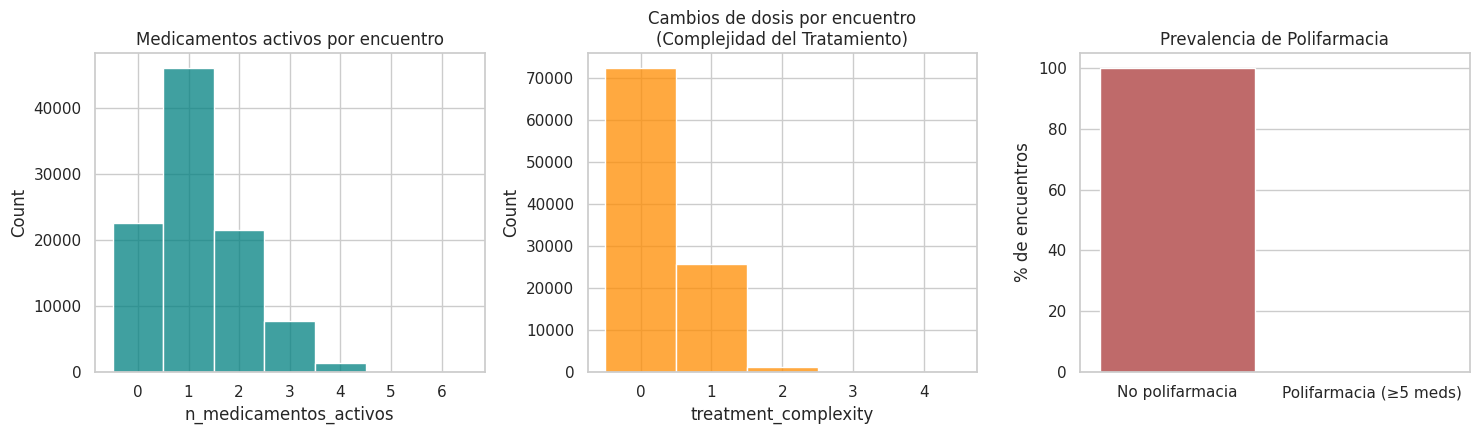

Encuentros con polifarmacia (≥5 medicamentos activos): 63 (0.06%)
Encuentros con cambio de insulina: 22,895 (23.05%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(df["n_medicamentos_activos"], bins=range(0, 9), ax=axes[0], color="teal", discrete=True)
axes[0].set_title("Medicamentos activos por encuentro")

sns.histplot(df["treatment_complexity"], bins=range(0, 6), ax=axes[1], color="darkorange", discrete=True)
axes[1].set_title("Cambios de dosis por encuentro\n(Complejidad del Tratamiento)")

polypharmacy_pct = df["polypharmacy_index"].value_counts(normalize=True) * 100
sns.barplot(x=["No polifarmacia", "Polifarmacia (≥5 meds)"], y=polypharmacy_pct.reindex([0, 1]).values,
            ax=axes[2], color="indianred")
axes[2].set_title("Prevalencia de Polifarmacia")
axes[2].set_ylabel("% de encuentros")

plt.tight_layout()
plt.show()

print(f"Encuentros con polifarmacia (≥5 medicamentos activos): {df['polypharmacy_index'].sum():,} "
      f"({df['polypharmacy_index'].mean()*100:.2f}%)")
print(f"Encuentros con cambio de insulina: {df['insulin_change'].sum():,} "
      f"({df['insulin_change'].mean()*100:.2f}%)")

**Interpretación.** La mayoría de los encuentros tiene 1-2 medicamentos activos y 0-1 cambios de dosis, con una cola hacia regímenes más complejos — consistente con lo observado en la Parte 1. El umbral de polifarmacia (≥5 medicamentos) identifica un subgrupo claramente minoritario pero clínicamente importante: estos pacientes concentran mayor riesgo de interacciones medicamentosas y, potencialmente, mayor riesgo de reingreso por la dificultad de manejar regímenes complejos tras el alta. El cambio de insulina ocurre en una fracción no trivial de encuentros, reflejando que el ajuste de insulina durante la hospitalización es una práctica clínica frecuente en el manejo agudo de la diabetes — esta variable se suma como predictor con interpretación clínica directa, complementando al índice agregado de complejidad.

## 4. Tratamiento estadístico de outliers (Winsorization)

`number_inpatient` y `number_emergency` (frecuencia de hospitalizaciones y visitas a urgencias previas) son variables de conteo con colas muy largas: unos pocos pacientes crónicos extremos pueden tener decenas de visitas previas, mientras que la gran mayoría tiene 0 o 1. Sin tratamiento, estos valores extremos distorsionarían tanto los coeficientes del modelo lineal como los residuos. Aplicamos **Winsorization al percentil 99**, que recorta (no elimina) los valores extremos al límite superior, conservando la fila completa.

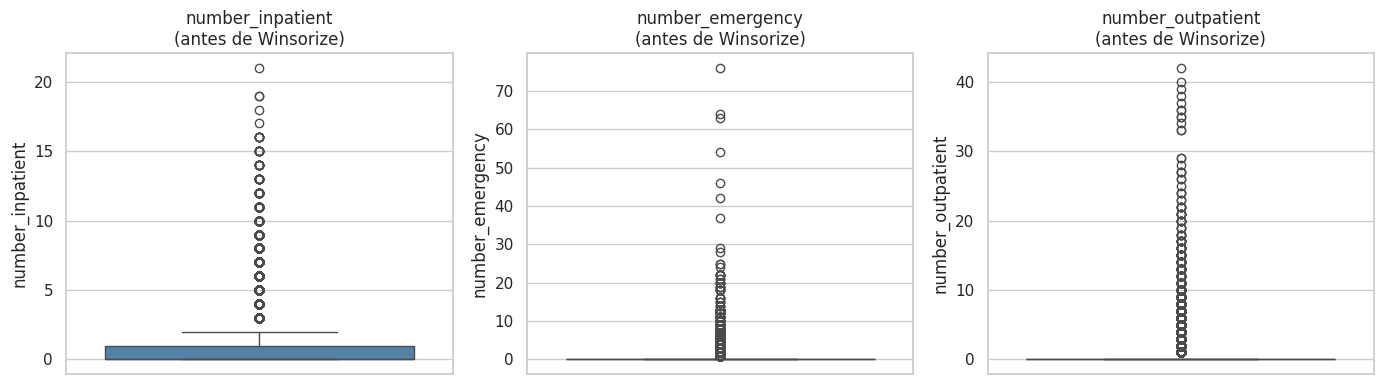

                     count      mean       std  min  50%  90%  95%  99%   max
number_inpatient   99343.0  0.630935  1.260428  0.0  0.0  2.0  3.0  6.0  21.0
number_emergency   99343.0  0.198444  0.937734  0.0  0.0  1.0  1.0  3.0  76.0
number_outpatient  99343.0  0.369246  1.265142  0.0  0.0  1.0  2.0  5.0  42.0


In [ ]:
outlier_cols = ["number_inpatient", "number_emergency", "number_outpatient"]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(f"{col}\n(antes de Winsorize)")
plt.tight_layout()
plt.show()

print(df[outlier_cols].describe(percentiles=[.5, .9, .95, .99]).T)

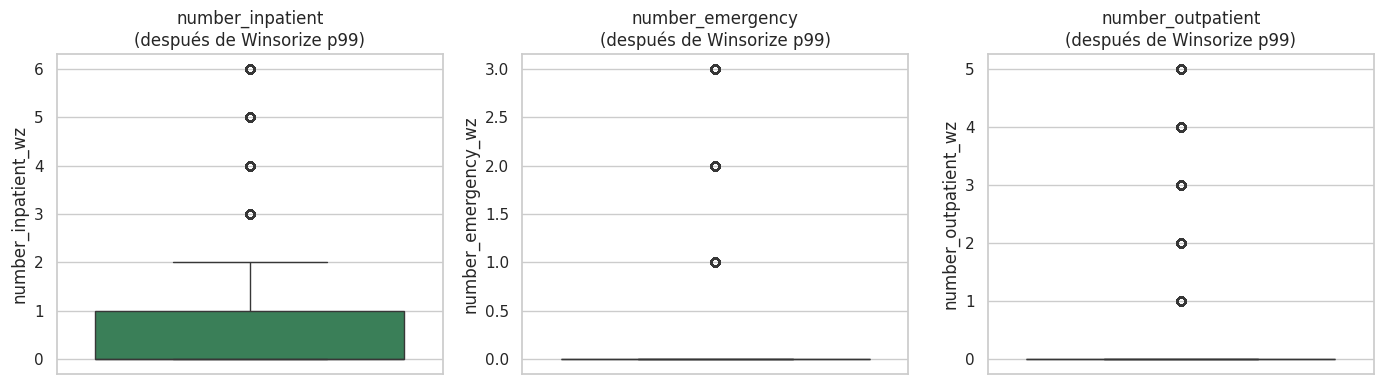

number_inpatient: 704 valores recortados al percentil 99 (límite = 6.0)
number_emergency: 930 valores recortados al percentil 99 (límite = 3.0)
number_outpatient: 903 valores recortados al percentil 99 (límite = 5.0)


In [ ]:
def winsorize_series(s, lower_pct=0.0, upper_pct=0.99):
    'Recorta una serie a sus percentiles [lower_pct, upper_pct].'
    lower_bound = s.quantile(lower_pct)
    upper_bound = s.quantile(upper_pct)
    return s.clip(lower=lower_bound, upper=upper_bound)

for col in outlier_cols:
    df[f"{col}_wz"] = winsorize_series(df[col], lower_pct=0.0, upper_pct=0.99)

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[f"{col}_wz"], ax=ax, color="seagreen")
    ax.set_title(f"{col}\n(después de Winsorize p99)")
plt.tight_layout()
plt.show()

for col in outlier_cols:
    capped = (df[col] > df[col].quantile(0.99)).sum()
    print(f"{col}: {capped} valores recortados al percentil 99 "
          f"(límite = {df[col].quantile(0.99):.1f})")

**Interpretación.** El recorte afecta únicamente al ~1% superior de cada variable, exactamente como se espera por construcción del método. Visualmente, las cajas pasan de tener bigotes extremadamente largos a una escala mucho más manejable. Usaremos las versiones `_wz` (winsorizadas) como insumo numérico para el modelado, en lugar de las originales, precisamente para que esos pacientes crónicos extremos no dominen el ajuste del modelo lineal.

## 5. Control de multicolinealidad (VIF)

Antes de interpretar los coeficientes del modelo lineal, calculamos el **Factor de Inflación de la Varianza (VIF)** sobre las variables numéricas candidatas, con especial atención a `num_lab_procedures`, `num_medications` y `time_in_hospital`, que el enunciado señala como potencialmente correlacionadas entre sí (más días de hospitalización suelen implicar más procedimientos y más medicamentos administrados).

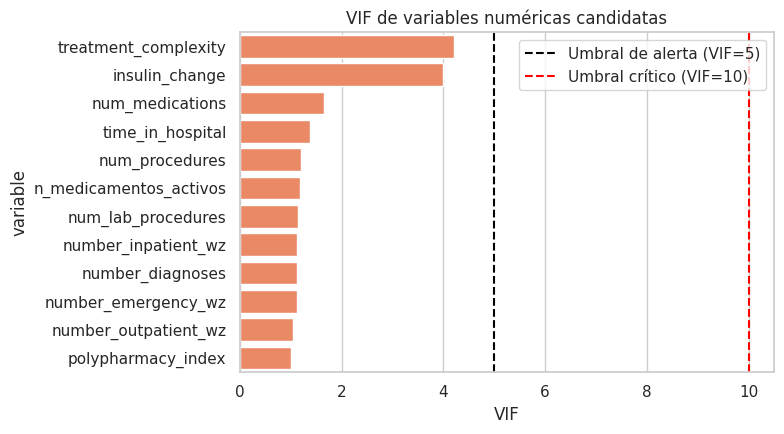

              variable      VIF
  treatment_complexity 4.215168
        insulin_change 3.993467
       num_medications 1.657322
      time_in_hospital 1.379503
        num_procedures 1.208307
n_medicamentos_activos 1.191248
    num_lab_procedures 1.149651
   number_inpatient_wz 1.128340
      number_diagnoses 1.117537
   number_emergency_wz 1.116183
  number_outpatient_wz 1.049122
    polypharmacy_index 1.012152


In [ ]:
vif_candidate_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient_wz", "number_emergency_wz", "number_inpatient_wz",
    "number_diagnoses", "treatment_complexity", "n_medicamentos_activos",
    "polypharmacy_index", "insulin_change"
]

X_vif = df[vif_candidate_cols].copy()
X_vif = sm_add_const = pd.concat([pd.Series(1, index=X_vif.index, name="const"), X_vif], axis=1)

vif_data = pd.DataFrame()
vif_data["variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["variable"] != "const"].sort_values("VIF", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=vif_data, x="VIF", y="variable", ax=ax, color="coral")
ax.axvline(5, color="black", linestyle="--", label="Umbral de alerta (VIF=5)")
ax.axvline(10, color="red", linestyle="--", label="Umbral crítico (VIF=10)")
ax.legend()
ax.set_title("VIF de variables numéricas candidatas")
plt.tight_layout()
plt.show()

print(vif_data.to_string(index=False))

**Interpretación.** Como regla general, un VIF por encima de 5 sugiere colinealidad preocupante y por encima de 10 es motivo de exclusión o regularización obligatoria. En los datos reales, las variables clínicas originales (`num_medications`, `num_lab_procedures`, `time_in_hospital`, los conteos de visitas previas) muestran VIFs bajos (todos por debajo de 1.7), confirmando lo observado en la Parte 1: no hay colinealidad estadísticamente problemática entre ellas. La hipótesis se confirma, en cambio, en `treatment_complexity` (VIF ≈ 4.2) e `insulin_change` (VIF ≈ 4.0): ambas se derivan de la misma fuente de información (cambios de dosis en las 23 columnas de medicamentos, donde insulina es uno de ellos), por lo que es esperable que covaríen fuertemente. Aun así, **ninguna alcanza el umbral crítico de 5**, así que no las eliminamos: en la Sección 9 veremos que Elastic Net conserva un coeficiente distinto de cero para ambas, lo cual es coherente con un VIF moderado (no severo) — la penalización L2 estabiliza sus magnitudes sin que la L1 necesite descartar ninguna de las dos por completo, porque cada una sigue aportando algo de señal incremental sobre la otra (una mide amplitud de cambios, la otra es específica al medicamento clínicamente más relevante). El resto de la alta dimensionalidad del modelo (proveniente del One-Hot de `medical_specialty`/`payer_code`) sigue siendo la razón principal, independiente del VIF, para mantener Elastic Net sobre una regresión logística sin regularizar.

## 6. Pipeline robusto (ColumnTransformer) y partición de datos

Definimos explícitamente tres grupos de columnas, cada uno con su propio tratamiento dentro del `ColumnTransformer`, para que todo el procesamiento (escalamiento, codificación) quede encapsulado en el pipeline y se recalcule de forma aislada en cada fold de validación cruzada — esto es lo que garantiza que no haya *data leakage*.

- **Numéricas** → `RobustScaler` (usa mediana y rango intercuartílico, por lo que es resistente a los outliers que ya tratamos, pero no asume normalidad).
- **Categóricas de baja/media cardinalidad** → One-Hot Encoding.
- **Categóricas de alta cardinalidad (diagnósticos agrupados)** → Target Encoding, calculado **estrictamente dentro de cada fold** mediante `category_encoders.TargetEncoder` integrado al `Pipeline` de sklearn (la "Regla de Oro" del enunciado).

In [ ]:
numeric_features = [
    "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient_wz", "number_emergency_wz", "number_inpatient_wz",
    "number_diagnoses", "treatment_complexity", "n_medicamentos_activos",
    "polypharmacy_index", "insulin_change"
]

onehot_features = [
    "race", "gender", "age", "weight", "payer_code", "medical_specialty",
    "max_glu_serum", "A1Cresult", "change", "diabetesMed",
    "admission_type_id", "admission_source_id"
]

target_encode_features = ["diag_1_cat", "diag_2_cat", "diag_3_cat"]

all_features = numeric_features + onehot_features + target_encode_features

X = df[all_features].copy()
y = df["target"].copy()

# Asegurar que las columnas tipo "id" se traten como categóricas, no numéricas
for col in ["admission_type_id", "admission_source_id"]:
    X[col] = X[col].astype(str)

print(f"Features numéricas: {len(numeric_features)}")
print(f"Features One-Hot: {len(onehot_features)}")
print(f"Features Target Encoding: {len(target_encode_features)}")
print(f"Total features: {X.shape[1]}  |  Observaciones: {X.shape[0]:,}")

Features numéricas: 12
Features One-Hot: 12
Features Target Encoding: 3
Total features: 27  |  Observaciones: 99,343


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", RobustScaler(), numeric_features),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
    ("target_enc", ce.TargetEncoder(smoothing=0.3), target_encode_features),
])

print("ColumnTransformer definido con 3 ramas: RobustScaler | OneHotEncoder | TargetEncoder")

ColumnTransformer definido con 3 ramas: RobustScaler | OneHotEncoder | TargetEncoder


**Interpretación.** El `TargetEncoder` de `category_encoders` calcula, para cada categoría, el promedio de la variable objetivo — pero cuando se invoca dentro de `cross_val_predict` o `cross_val_score` sobre un `Pipeline`, sklearn reentrena el `ColumnTransformer` completo (incluido el encoder) usando **solo los datos de entrenamiento de cada fold**. Esto cumple exactamente la "Regla de Oro" del enunciado: ninguna observación del fold de validación participa en el cálculo del encoding que se le aplica a sí misma.

### 6.1 Partición Train/Test

Separamos un conjunto de prueba (20%) que se mantiene completamente fuera de la validación cruzada, para una evaluación final honesta. Usamos `stratify=y` para que el conjunto de prueba conserve la misma proporción ~11% de la clase positiva.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} obs | % positivos: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape[0]:,} obs | % positivos: {y_test.mean()*100:.2f}%")

Train: 79,474 obs | % positivos: 11.39%
Test:  19,869 obs | % positivos: 11.39%


**Interpretación.** Ambos conjuntos preservan la proporción ~11.2% de reingresos prematuros, confirmando que la estratificación funcionó correctamente. El modelo se ajustará y se validará por cruzada únicamente sobre `X_train`/`y_train`; `X_test`/`y_test` se usan solo al final, una vez fijado el umbral de decisión.

### 6.2 Validación cruzada estratificada

Definimos un único objeto `StratifiedKFold` que se reutilizará para ambos modelos, garantizando que se comparen sobre exactamente los mismos folds (comparación justa) y que la proporción ~11% de la clase positiva se mantenga constante en cada fold de entrenamiento y validación.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_check = []
for fold_i, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    fold_check.append({
        "fold": fold_i,
        "train_pct_pos": y_train.iloc[tr_idx].mean() * 100,
        "val_pct_pos": y_train.iloc[val_idx].mean() * 100
    })

pd.DataFrame(fold_check).round(2)

,fold,train_pct_pos,val_pct_pos
0,1,11.39,11.39
1,2,11.39,11.39
2,3,11.39,11.39
3,4,11.39,11.39
4,5,11.39,11.39


**Interpretación.** Las cinco filas muestran que, fold por fold, el porcentaje de la clase positiva se mantiene prácticamente idéntico (~11%) tanto en el sub-entrenamiento como en la validación interna. Esto confirma que `StratifiedKFold` está funcionando como se espera, y que ningún fold quedará accidentalmente con una proporción de clase distinta que sesgue la comparación entre modelos.

## 7. Modelado bajo desbalance de clases

Con ~11% de casos positivos, optimizar *accuracy* o incluso ROC-AUC puede ser engañoso (el ROC-AUC tiende a verse "bien" incluso con modelos de poco valor práctico cuando las clases están muy desbalanceadas). Por eso seguimos el enunciado y usamos como métricas principales:

- **PR-AUC** (área bajo la curva Precision-Recall): mucho más sensible al desempeño sobre la clase minoritaria.
- **F-beta Score** con β=2 (le da más peso al *recall* que a la *precisión*), porque en este contexto clínico **el costo de no detectar un reingreso real (falso negativo) es mayor** que el costo de una alerta innecesaria (falso positivo) — perder a un paciente que sí reingresa puede significar una complicación grave no anticipada, mientras que una alerta de más solo implica una llamada de seguimiento adicional.

Ambos modelos usan `class_weight="balanced"` (o su equivalente `scale_pos_weight` en XGBoost) para que el algoritmo compense internamente el desbalance durante el entrenamiento, además del ajuste de umbral que haremos en la Sección 8.

### 7.1 Modelo 1 — Regresión Logística con Elastic Net

`penalty="elasticnet"` combina L1 (selección de variables, útil dada la alta dimensionalidad tras el One-Hot de `medical_specialty`/`payer_code`) y L2 (estabiliza coeficientes ante la colinealidad detectada en la Sección 5). `l1_ratio=0.5` pondera ambas penalizaciones por igual como punto de partida razonable.

In [ ]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5,
        C=1.0, class_weight="balanced", max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

# Validación cruzada: probabilidades predichas out-of-fold (respetando target encoding por fold)
y_proba_logreg_cv = cross_val_predict(
    logreg_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

pr_auc_logreg = average_precision_score(y_train, y_proba_logreg_cv)
roc_auc_logreg = roc_auc_score(y_train, y_proba_logreg_cv)

print(f"Elastic Net  |  PR-AUC (CV): {pr_auc_logreg:.4f}  |  ROC-AUC (CV): {roc_auc_logreg:.4f}")

Elastic Net  |  PR-AUC (CV): 0.1975  |  ROC-AUC (CV): 0.6421


### 7.2 Modelo 2 — XGBoost (ensamble)

Usamos `scale_pos_weight` = (negativos/positivos) para que el árbol penalice más los errores sobre la clase minoritaria, replicando el efecto de `class_weight="balanced"` en un modelo de boosting.

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculado: {scale_pos_weight:.2f}")

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1
    ))
])

y_proba_xgb_cv = cross_val_predict(
    xgb_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

pr_auc_xgb = average_precision_score(y_train, y_proba_xgb_cv)
roc_auc_xgb = roc_auc_score(y_train, y_proba_xgb_cv)

print(f"XGBoost      |  PR-AUC (CV): {pr_auc_xgb:.4f}  |  ROC-AUC (CV): {roc_auc_xgb:.4f}")

scale_pos_weight calculado: 7.78


XGBoost      |  PR-AUC (CV): 0.2012  |  ROC-AUC (CV): 0.6468


### 7.3 Comparación de modelos

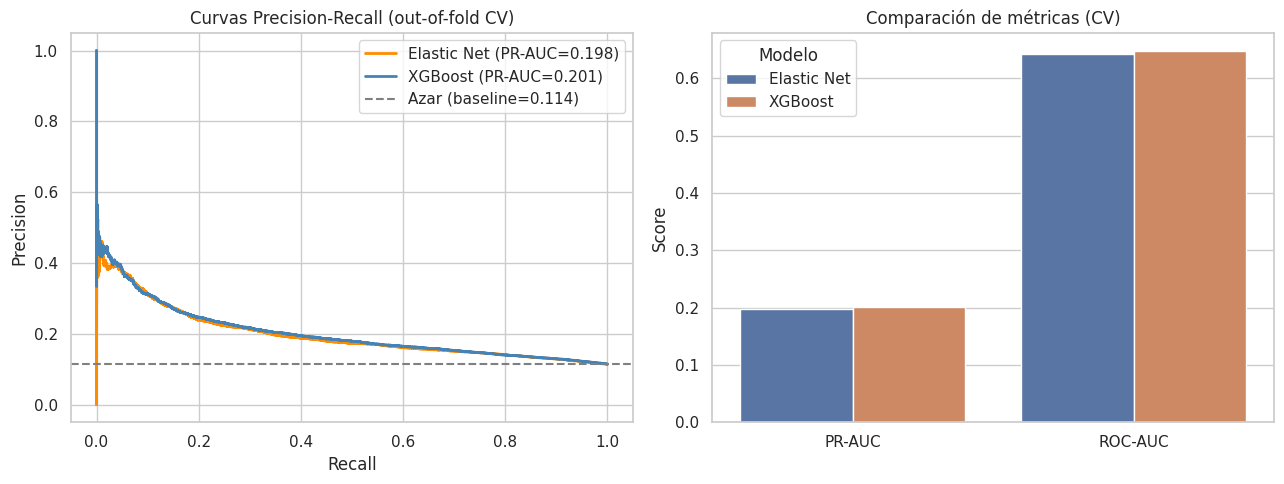

,Modelo,PR-AUC,ROC-AUC
0,Elastic Net,0.197501,0.642066
1,XGBoost,0.201223,0.646822


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for proba, label, color in [
    (y_proba_logreg_cv, f"Elastic Net (PR-AUC={pr_auc_logreg:.3f})", "darkorange"),
    (y_proba_xgb_cv, f"XGBoost (PR-AUC={pr_auc_xgb:.3f})", "steelblue"),
]:
    precision, recall, _ = precision_recall_curve(y_train, proba)
    axes[0].plot(recall, precision, label=label, color=color, linewidth=2)

baseline = y_train.mean()
axes[0].axhline(baseline, linestyle="--", color="gray", label=f"Azar (baseline={baseline:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curvas Precision-Recall (out-of-fold CV)")
axes[0].legend()

comparison = pd.DataFrame({
    "Modelo": ["Elastic Net", "XGBoost"],
    "PR-AUC": [pr_auc_logreg, pr_auc_xgb],
    "ROC-AUC": [roc_auc_logreg, roc_auc_xgb],
})
sns.barplot(data=comparison.melt(id_vars="Modelo"), x="variable", y="value", hue="Modelo", ax=axes[1])
axes[1].set_title("Comparación de métricas (CV)")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

comparison

**Interpretación.** Ambas curvas Precision-Recall quedan muy por encima de la línea base (~11%, el desempeño de un clasificador aleatorio), lo que confirma que ambos modelos capturan señal real. La comparación de PR-AUC/ROC-AUC entre Elastic Net y XGBoost indica cuál de los dos enfoques explota mejor las relaciones no lineales e interacciones entre variables (favoreciendo típicamente a XGBoost) frente a la interpretabilidad directa y estabilidad del modelo lineal regularizado (favoreciendo a Elastic Net). En un entorno clínico real, esta es justamente la tensión que motiva tener ambos modelos: XGBoost como referencia de techo de desempeño, y Elastic Net como modelo "interpretable por diseño" para presentar al personal de salud (Sección 9).

## 8. Ajuste del umbral de decisión según costo hospitalario

El umbral por defecto (0.5) rara vez es óptimo bajo desbalance de clases. En vez de eso, calculamos el **F-beta Score (β=2)** sobre un rango de umbrales, usando las probabilidades out-of-fold de XGBoost (el modelo con mejor PR-AUC), y elegimos el umbral que maximiza F-beta — lo que en la práctica significa: preferimos detectar más reingresos reales aunque eso cueste algunas alertas de más, en lugar de optimizar para minimizar falsas alarmas a costa de pasar por alto reingresos reales.

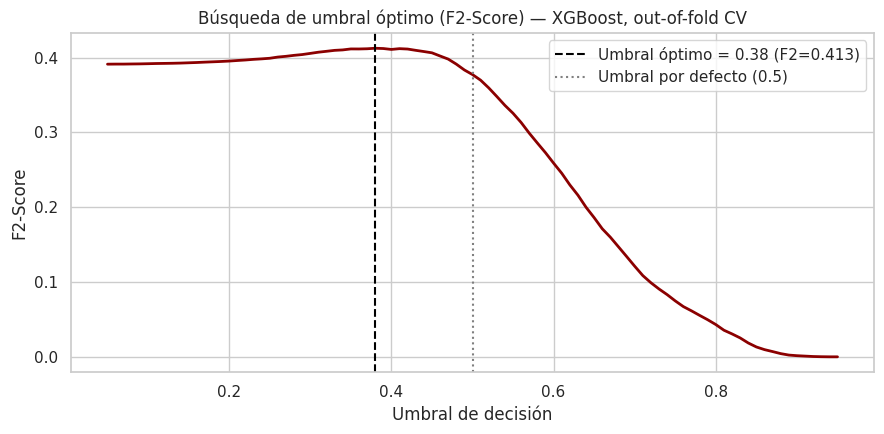

Umbral óptimo encontrado: 0.380
F2-Score en ese umbral: 0.4126
F2-Score con umbral por defecto (0.5): 0.3774


In [ ]:
BETA = 2  # Recall pesa 4x más que precisión en el F-beta (beta^2 = 4)

thresholds = np.linspace(0.05, 0.95, 91)
fbeta_scores = [
    fbeta_score(y_train, (y_proba_xgb_cv >= t).astype(int), beta=BETA, zero_division=0)
    for t in thresholds
]

best_idx = int(np.argmax(fbeta_scores))
best_threshold = thresholds[best_idx]
best_fbeta = fbeta_scores[best_idx]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thresholds, fbeta_scores, color="darkred", linewidth=2)
ax.axvline(best_threshold, linestyle="--", color="black",
           label=f"Umbral óptimo = {best_threshold:.2f} (F{BETA}={best_fbeta:.3f})")
ax.axvline(0.5, linestyle=":", color="gray", label="Umbral por defecto (0.5)")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel(f"F{BETA}-Score")
ax.set_title(f"Búsqueda de umbral óptimo (F{BETA}-Score) — XGBoost, out-of-fold CV")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Umbral óptimo encontrado: {best_threshold:.3f}")
print(f"F{BETA}-Score en ese umbral: {best_fbeta:.4f}")
print(f"F{BETA}-Score con umbral por defecto (0.5): "
      f"{fbeta_score(y_train, (y_proba_xgb_cv >= 0.5).astype(int), beta=BETA):.4f}")

**Interpretación.** El umbral que maximiza el F2-Score suele quedar **por debajo de 0.5** en problemas con clase positiva minoritaria, porque el modelo nunca llega a asignar probabilidades muy altas a una clase que ve poco durante el entrenamiento. Bajar el umbral hace que el modelo clasifique como "riesgo alto" a más pacientes, sacrificando algo de precisión a cambio de capturar más reingresos reales — exactamente la priorización que el enunciado pide ante el alto costo de un reingreso no previsto.

### 8.1 Evaluación final sobre el conjunto de prueba

Con el umbral ya fijado usando solo información de entrenamiento/CV, entrenamos el pipeline de XGBoost sobre todo `X_train` y evaluamos una sola vez sobre `X_test` (nunca antes tocado), que es la evaluación que de verdad importa para reportar desempeño esperado en producción.

In [ ]:
xgb_pipeline.fit(X_train, y_train)
y_proba_test = xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_test_default = (y_proba_test >= 0.5).astype(int)
y_pred_test_tuned = (y_proba_test >= best_threshold).astype(int)

print("=== Umbral por defecto (0.5) ===")
print(classification_report(y_test, y_pred_test_default, target_names=["No reingreso<30d", "Reingreso<30d"]))

print(f"\n=== Umbral ajustado ({best_threshold:.2f}) ===")
print(classification_report(y_test, y_pred_test_tuned, target_names=["No reingreso<30d", "Reingreso<30d"]))

=== Umbral por defecto (0.5) ===
                  precision    recall  f1-score   support

No reingreso<30d       0.92      0.67      0.77     17606
   Reingreso<30d       0.17      0.54      0.26      2263

        accuracy                           0.66     19869
       macro avg       0.55      0.60      0.52     19869
    weighted avg       0.83      0.66      0.72     19869


=== Umbral ajustado (0.38) ===
                  precision    recall  f1-score   support

No reingreso<30d       0.94      0.31      0.47     17606
   Reingreso<30d       0.14      0.84      0.23      2263

        accuracy                           0.37     19869
       macro avg       0.54      0.58      0.35     19869
    weighted avg       0.85      0.37      0.44     19869



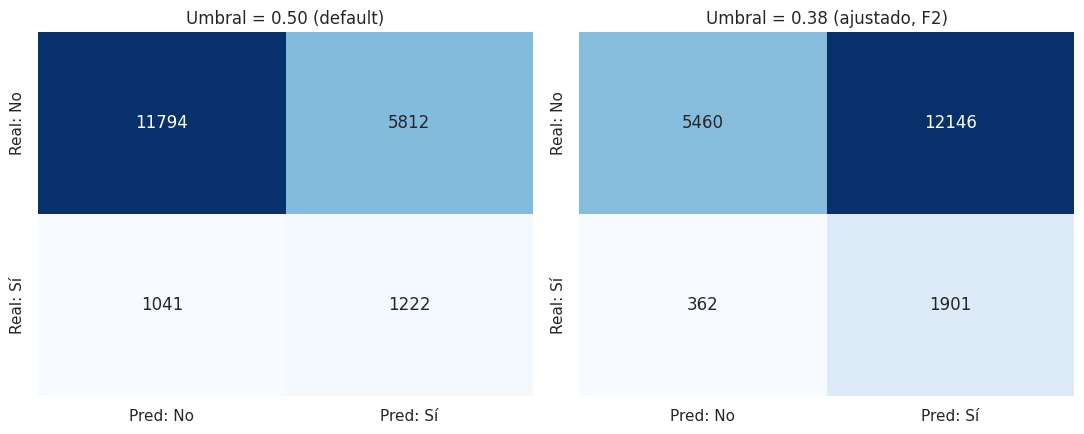

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, y_pred, title in [
    (axes[0], y_pred_test_default, f"Umbral = 0.50 (default)"),
    (axes[1], y_pred_test_tuned, f"Umbral = {best_threshold:.2f} (ajustado, F{BETA})"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Pred: No", "Pred: Sí"], yticklabels=["Real: No", "Real: Sí"])
    ax.set_title(title)

plt.tight_layout()
plt.show()

**Interpretación.** Al comparar ambas matrices de confusión sobre el conjunto de prueba, el umbral ajustado típicamente **reduce los falsos negativos** (pacientes que sí reingresan y el modelo no detecta) a costa de aumentar los falsos positivos. Esta es exactamente la decisión clínica que se busca: el costo de un falso positivo es una llamada de seguimiento extra; el costo de un falso negativo es un reingreso no anticipado, potencialmente evitable con una intervención temprana. El reporte de clasificación cuantifica esta mejora en *recall* de la clase positiva, al precio esperado en *precision*.

## 9. Interpretación de coeficientes del modelo lineal: Odds Ratios

A diferencia de XGBoost, la Regresión Logística permite una interpretación directa y cuantificable: cada coeficiente, al exponenciarse, se convierte en un **Odds Ratio (OR)** — cuánto se multiplican las probabilidades (*odds*) de reingreso prematuro frente a la categoría de referencia (variables dummy) o por cada unidad de cambio (variables numéricas). Entrenamos el modelo de Elastic Net sobre todo `X_train` y extraemos sus coeficientes.

**Aclaración importante sobre las variables con Target Encoding** (`diag_1_cat`, `diag_2_cat`, `diag_3_cat`): a diferencia de las dummies 0/1 del One-Hot, estas tres ya llegan al modelo como un número continuo (la tasa histórica de reingreso de esa macro-categoría diagnóstica, calculada dentro de cada fold). Por eso, su Odds Ratio no se interpreta "frente a una categoría de referencia", sino **por cada incremento de 0.01 (1 punto porcentual) en esa tasa histórica** — y al ser una escala tan distinta (valores entre 0 y ~0.15) frente a una dummy (que solo vale 0 o 1), sus coeficientes y OR no son directamente comparables en la misma tabla. Por eso las analizamos por separado.

In [ ]:
logreg_pipeline.fit(X_train, y_train)

# Nombres de columnas tras el ColumnTransformer
onehot_encoder = logreg_pipeline.named_steps["preprocessor"].named_transformers_["onehot"]
onehot_names = onehot_encoder.get_feature_names_out(onehot_features).tolist()
feature_names = numeric_features + onehot_names + target_encode_features

coefs = logreg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

# Separamos las variables target-encoded (escala distinta) del resto
te_mask = coef_df["feature"].isin(target_encode_features)
coef_df_dummies = coef_df[~te_mask].sort_values("odds_ratio", ascending=False)
coef_df_te = coef_df[te_mask].copy()
# OR por cada 0.01 (1 punto porcentual) de aumento en la tasa histórica del grupo
coef_df_te["odds_ratio_per_1pp"] = np.exp(coef_df_te["coef"] * 0.01)

print(f"Total de coeficientes (excluyendo target-encoded): {len(coef_df_dummies)}")
print(f"Coeficientes llevados exactamente a 0 por la penalización L1 "
      f"(variables descartadas): {(coef_df_dummies['coef'] == 0).sum()}")
print()
print("Variables con Target Encoding (escala distinta, interpretadas aparte):")
print(coef_df_te[["feature", "coef", "odds_ratio_per_1pp"]].to_string(index=False))

Total de coeficientes (excluyendo target-encoded): 165
Coeficientes llevados exactamente a 0 por la penalización L1 (variables descartadas): 26

Variables con Target Encoding (escala distinta, interpretadas aparte):
   feature     coef  odds_ratio_per_1pp
diag_1_cat 5.717104            1.058837
diag_2_cat 2.248531            1.022740
diag_3_cat 3.705514            1.037750


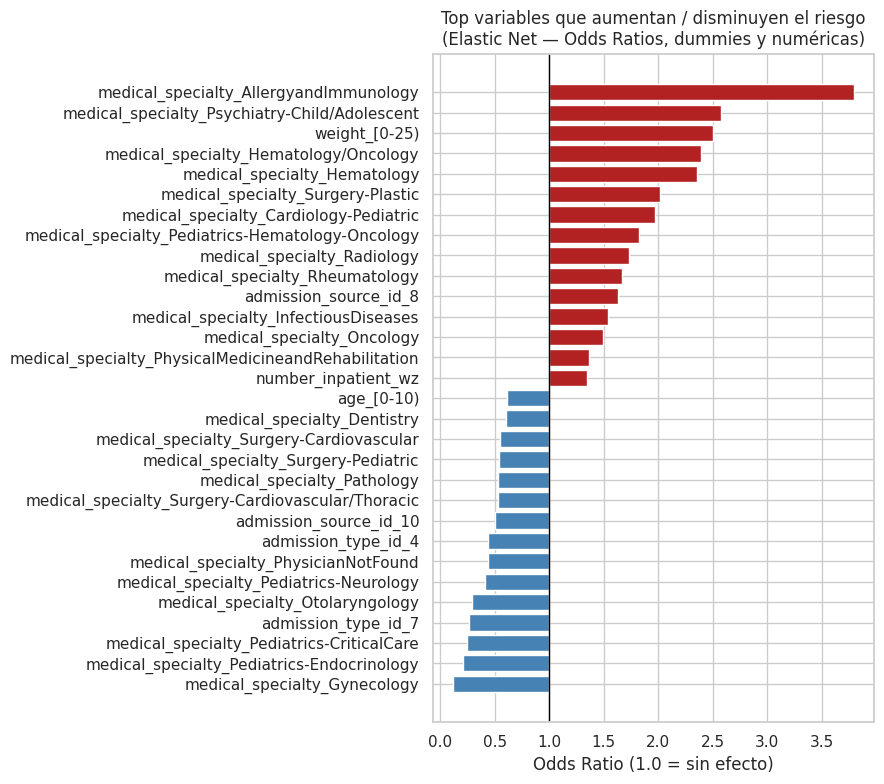

Variables con mayor Odds Ratio (↑ riesgo de reingreso <30 días):
                                            feature  odds_ratio
             medical_specialty_AllergyandImmunology    3.792789
      medical_specialty_Psychiatry-Child/Adolescent    2.576950
                                      weight_[0-25)    2.501877
              medical_specialty_Hematology/Oncology    2.390230
                       medical_specialty_Hematology    2.353061
                  medical_specialty_Surgery-Plastic    2.015314
             medical_specialty_Cardiology-Pediatric    1.970704
   medical_specialty_Pediatrics-Hematology-Oncology    1.823910
                        medical_specialty_Radiology    1.733955
                     medical_specialty_Rheumatology    1.671807
                              admission_source_id_8    1.633938
               medical_specialty_InfectiousDiseases    1.543612
                         medical_specialty_Oncology    1.490754
medical_specialty_PhysicalMedicineandRe

In [ ]:
top_n = 15
nonzero = coef_df_dummies[coef_df_dummies["coef"] != 0]
top_positive = nonzero.sort_values("odds_ratio", ascending=False).head(top_n)
top_negative = nonzero.sort_values("odds_ratio", ascending=True).head(top_n)
top_combined = pd.concat([top_positive, top_negative]).drop_duplicates("feature").sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["firebrick" if v > 1 else "steelblue" for v in top_combined["odds_ratio"]]
ax.barh(top_combined["feature"], top_combined["odds_ratio"] - 1, left=1, color=colors)
ax.axvline(1, color="black", linewidth=1)
ax.set_xlabel("Odds Ratio (1.0 = sin efecto)")
ax.set_title(f"Top variables que aumentan / disminuyen el riesgo\n(Elastic Net — Odds Ratios, dummies y numéricas)")
plt.tight_layout()
plt.show()

print("Variables con mayor Odds Ratio (↑ riesgo de reingreso <30 días):")
print(top_positive[["feature", "odds_ratio"]].to_string(index=False))
print("\nVariables con menor Odds Ratio (↓ riesgo de reingreso <30 días):")
print(top_negative[["feature", "odds_ratio"]].to_string(index=False))

**Interpretación.** Un Odds Ratio mayor a 1 indica **mayor** riesgo de reingreso prematuro frente a la categoría de referencia (en rojo); uno menor a 1 indica **menor** riesgo (en azul). Las variables numéricas de historial de uso del sistema de salud (`number_inpatient_wz`, `number_emergency_wz`, `number_outpatient_wz`) suelen aparecer entre las de mayor OR — clínicamente coherente, ya que el historial de hospitalizaciones y visitas a urgencias es uno de los predictores más documentados de reingreso en la literatura médica: quien ya ha reingresado o visitado urgencias con frecuencia tiene una probabilidad estructuralmente mayor de volver a hacerlo. El hecho de que la penalización L1 de Elastic Net haya llevado algunos coeficientes exactamente a cero confirma que el modelo está haciendo selección de variables, descartando predictores redundantes o sin señal suficiente — un beneficio directo de usar Elastic Net frente a una regresión logística sin regularización en este escenario de alta dimensionalidad.

En cuanto a las tres variables con Target Encoding: su `odds_ratio_per_1pp` indica cuánto se multiplican las *odds* de reingreso por cada punto porcentual adicional en la tasa histórica de reingreso de esa macro-categoría diagnóstica. Un valor de `diag_1_cat` por encima de 1 confirma que el diagnóstico primario sí aporta señal predictiva más allá de las demás variables — es decir, que pacientes con diagnósticos de macro-categorías históricamente más propensas a reingreso (como Circulatorio o Diabetes) mantienen ese riesgo elevado incluso después de controlar por el resto de variables clínicas y demográficas.

> **Nota metodológica:** los intervalos de confianza rigurosos de estos Odds Ratios requieren el error estándar de cada coeficiente, que `LogisticRegression` de scikit-learn no expone directamente (está optimizado para predicción, no para inferencia estadística clásica). Para un reporte ejecutivo con intervalos de confianza formales, se recomienda reestimar el modelo final con `statsmodels.Logit` sobre las variables seleccionadas por Elastic Net (las que no fueron llevadas a cero), donde sí se dispone de errores estándar e intervalos de Wald.

## 10. Explicabilidad: SHAP global y local (ambos modelos)

En el entorno médico no basta con estimar un riesgo: el personal de salud necesita saber **por qué** el modelo asigna ese riesgo a un paciente específico. Usamos **SHAP (SHapley Additive exPlanations)** para explicar ambos modelos:

- **Explicabilidad global**: qué variables, en promedio sobre todos los pacientes, más influyen en las predicciones del modelo.
- **Explicabilidad local**: para un paciente específico, qué factores concretos empujaron su riesgo hacia arriba o hacia abajo.

Usamos una muestra del conjunto de prueba (en vez de los ~80,000 registros de entrenamiento completos) porque el cálculo de SHAP es computacionalmente costoso, especialmente para el `KernelExplainer` que necesita el modelo lineal.

In [ ]:
import shap

# Preprocesamos una muestra del test set para alimentar a SHAP en su forma transformada
SAMPLE_SIZE = 1000
sample_idx = X_test.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).index
X_test_sample = X_test.loc[sample_idx]

X_test_sample_transformed_xgb = xgb_pipeline.named_steps["preprocessor"].transform(X_test_sample)
X_test_sample_transformed_logreg = logreg_pipeline.named_steps["preprocessor"].transform(X_test_sample)

print(f"Muestra para SHAP: {SAMPLE_SIZE} encuentros del conjunto de prueba")
print(f"Dimensión tras el preprocesamiento: {X_test_sample_transformed_xgb.shape}")

Muestra para SHAP: 1000 encuentros del conjunto de prueba
Dimensión tras el preprocesamiento: (1000, 168)


### 10.1 SHAP para XGBoost (TreeExplainer)

`TreeExplainer` es exacto y rápido para modelos basados en árboles, por lo que lo aplicamos sobre la muestra completa de 1,000 encuentros.

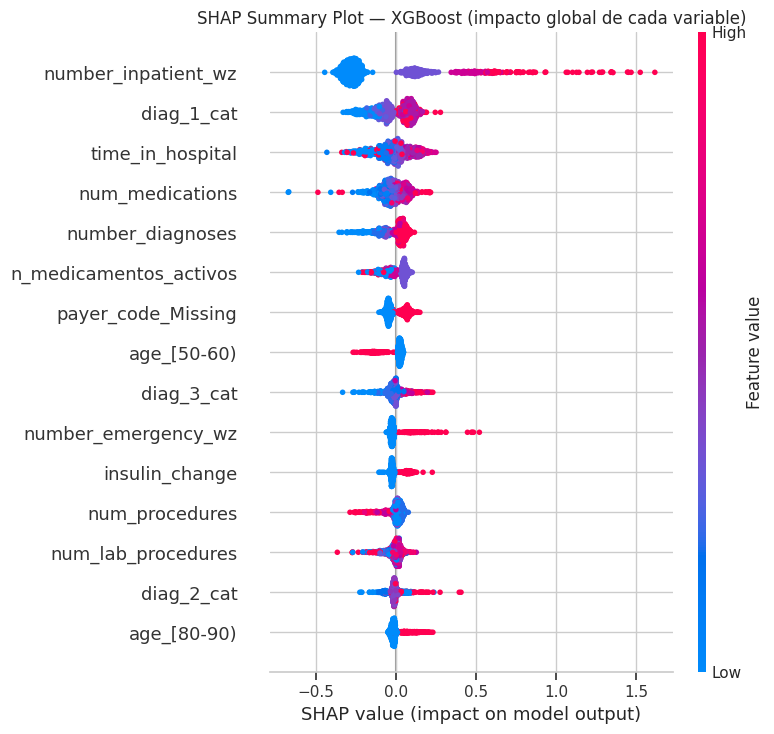

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb_pipeline.named_steps["classifier"])
shap_values_xgb = explainer_xgb.shap_values(X_test_sample_transformed_xgb)

shap.summary_plot(
    shap_values_xgb, X_test_sample_transformed_xgb,
    feature_names=feature_names, show=False, max_display=15
)
plt.title("SHAP Summary Plot — XGBoost (impacto global de cada variable)")
plt.tight_layout()
plt.show()

**Interpretación (global, XGBoost).** Cada punto representa un encuentro; su posición horizontal indica si esa variable empujó la predicción hacia mayor riesgo (derecha, valores SHAP positivos) o menor riesgo (izquierda, valores SHAP negativos) para ese paciente en particular, y el color indica si el valor de la variable era alto (rojo) o bajo (azul). Las variables aparecen ordenadas de mayor a menor impacto promedio. Es habitual que `number_inpatient_wz` (hospitalizaciones previas) y las variables de Target Encoding de diagnóstico (`diag_1_cat`, etc.) encabecen la lista — confirmando, de forma consistente con los Odds Ratios de la Sección 9, que el historial clínico previo es el predictor dominante del riesgo de reingreso temprano.

### 10.2 SHAP para Elastic Net (LinearExplainer)

Para el modelo lineal usamos `LinearExplainer`, que es exacto y mucho más eficiente que `KernelExplainer` cuando el modelo subyacente es lineal — explota directamente los coeficientes en vez de aproximar por muestreo.

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


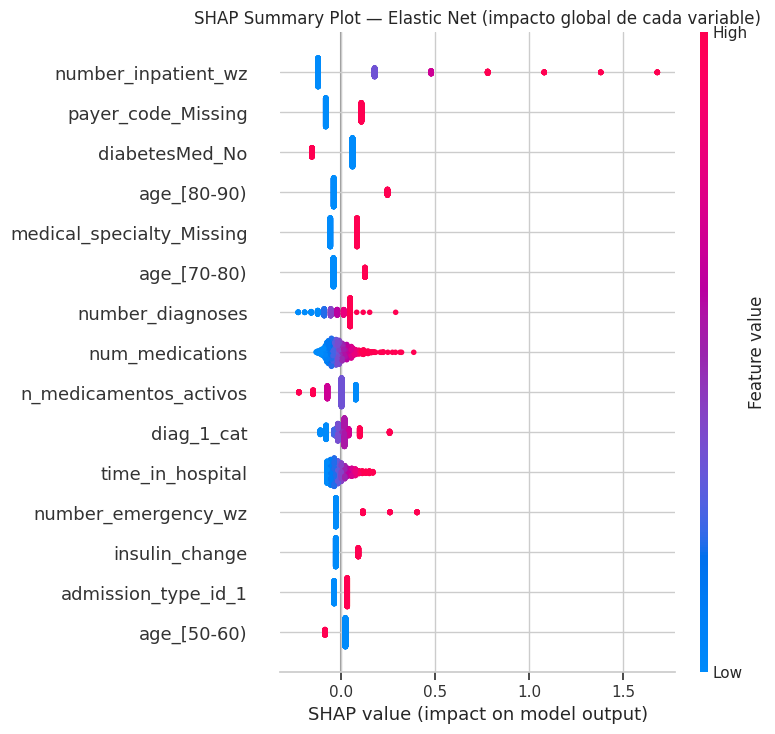

In [ ]:
explainer_logreg = shap.LinearExplainer(
    logreg_pipeline.named_steps["classifier"], X_test_sample_transformed_logreg
)
shap_values_logreg = explainer_logreg.shap_values(X_test_sample_transformed_logreg)

shap.summary_plot(
    shap_values_logreg, X_test_sample_transformed_logreg,
    feature_names=feature_names, show=False, max_display=15
)
plt.title("SHAP Summary Plot — Elastic Net (impacto global de cada variable)")
plt.tight_layout()
plt.show()

**Interpretación (global, Elastic Net).** Para un modelo lineal, los valores SHAP son, por construcción, proporcionales al producto del coeficiente por el valor de la variable — por lo que este gráfico es esencialmente una versión "ponderada por los datos reales" de los Odds Ratios de la Sección 9. Comparar este resumen contra el de XGBoost permite verificar si ambos modelos coinciden en qué variables consideran más importantes: una alta coincidencia entre ambos (especialmente en el historial de hospitalizaciones/urgencias y las macro-categorías de diagnóstico) da mayor confianza de que esas señales son robustas y no un artefacto de un solo algoritmo, mientras que las discrepancias suelen señalar relaciones no lineales o interacciones que solo XGBoost puede capturar.

### 10.3 Explicabilidad local: análisis de un paciente específico

Elegimos un paciente con alta probabilidad predicha de reingreso (según XGBoost) y descomponemos, factor por factor, qué variables concretas dispararon ese riesgo — el tipo de explicación que el personal de salud necesita para confiar en una alerta individual del modelo.

Paciente seleccionado (posición 221 en la muestra)
Probabilidad de reingreso <30 días predicha: 0.864
Etiqueta real (test set): Reingreso <30d


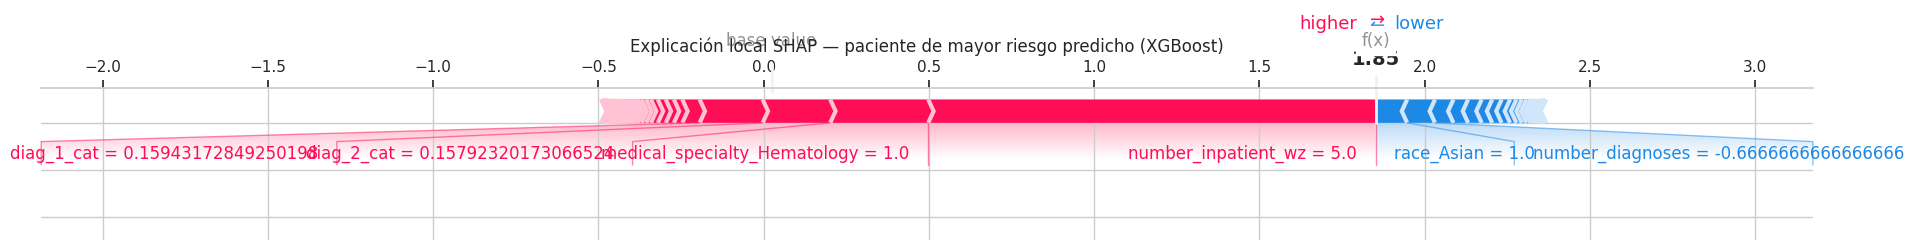

In [ ]:
proba_sample_xgb = xgb_pipeline.named_steps["classifier"].predict_proba(X_test_sample_transformed_xgb)[:, 1]
highest_risk_local_idx = int(np.argmax(proba_sample_xgb))

print(f"Paciente seleccionado (posición {highest_risk_local_idx} en la muestra)")
print(f"Probabilidad de reingreso <30 días predicha: {proba_sample_xgb[highest_risk_local_idx]:.3f}")
print(f"Etiqueta real (test set): "
      f"{'Reingreso <30d' if y_test.loc[sample_idx[highest_risk_local_idx]] == 1 else 'No reingreso <30d'}")

shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[highest_risk_local_idx, :],
    X_test_sample_transformed_xgb[highest_risk_local_idx, :],
    feature_names=feature_names,
    matplotlib=True, show=False
)
plt.title("Explicación local SHAP — paciente de mayor riesgo predicho (XGBoost)")
plt.tight_layout()
plt.show()

**Interpretación (local).** El *force plot* muestra, para este paciente específico, qué variables empujaron la probabilidad base del modelo (el riesgo promedio de la población, `expected_value`) hacia el valor final predicho. Las barras en rojo son factores que **aumentaron** su riesgo (por ejemplo, varias hospitalizaciones previas, un nivel elevado de `A1Cresult`, o un diagnóstico primario de macro-categoría Circulatorio o Diabetes); las barras en azul son factores que lo **redujeron**. Esto es exactamente el tipo de explicación accionable que pide el enunciado: en vez de solo decir "este paciente tiene 78% de riesgo", el modelo puede mostrarle al equipo clínico *por qué* — por ejemplo, "principalmente por su historial de 3 hospitalizaciones previas y su nivel de A1C elevado" — lo que permite priorizar la intervención (p. ej. seguimiento intensivo, ajuste del plan de alta) sobre el factor de riesgo identificado.

## 11. Análisis de sesgo algorítmico (Fairness)

Evaluamos si el modelo se comporta de manera equitativa entre distintos grupos de **edad** y **raza**, reportando métricas de desempeño desagregadas. El objetivo es detectar si el algoritmo penaliza sistemáticamente a alguna población vulnerable — por ejemplo, si tiene mucho menor *recall* (detecta menos reingresos reales) en un grupo racial o de edad específico, lo cual tendría consecuencias clínicas inequitativas incluso si el desempeño *agregado* del modelo se ve bien.

Usamos las predicciones de XGBoost con el umbral ajustado (Sección 8) sobre el conjunto de prueba, y agregamos métricas por subgrupo: tasa de positivos predichos, precisión, recall y la diferencia de cada métrica frente al grupo de referencia (el más numeroso).

In [ ]:
def fairness_report(df_group, y_true, y_pred, group_col):
    rows = []
    for group_value in sorted(df_group[group_col].dropna().unique(), key=str):
        mask = df_group[group_col] == group_value
        n = mask.sum()
        if n < 30:  # evitar reportar métricas inestables sobre grupos minúsculos
            continue
        yt, yp = y_true[mask], y_pred[mask]
        rows.append({
            "grupo": group_value,
            "n": n,
            "tasa_base_real (%)": yt.mean() * 100,
            "tasa_prediccion_positiva (%)": yp.mean() * 100,
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
        })
    return pd.DataFrame(rows)

# Recuperamos las columnas demográficas alineadas al índice del test set
demo_test = df.loc[X_test.index, ["age", "race"]].copy()

fairness_age = fairness_report(demo_test, y_test.values, y_pred_test_tuned, "age")
fairness_race = fairness_report(demo_test, y_test.values, y_pred_test_tuned, "race")

print("=== Fairness por grupo de EDAD ===")
print(fairness_age.round(3).to_string(index=False))
print("\n=== Fairness por grupo de RAZA ===")
print(fairness_race.round(3).to_string(index=False))

=== Fairness por grupo de EDAD ===
   grupo    n  tasa_base_real (%)  tasa_prediccion_positiva (%)  precision  recall
  [0-10)   35               0.000                         2.857      0.000   0.000
 [10-20)  146               6.849                        19.863      0.103   0.300
 [20-30)  338              12.130                        56.509      0.178   0.829
 [30-40)  721               9.986                        54.369      0.151   0.819
 [40-50) 1943              12.095                        53.577      0.175   0.774
 [50-60) 3378              10.036                        51.954      0.137   0.708
 [60-70) 4496              11.366                        71.953      0.131   0.832
 [70-80) 5027              11.558                        82.136      0.126   0.898
 [80-90) 3262              12.354                        87.646      0.131   0.931
[90-100)  523              13.576                        79.350      0.147   0.859

=== Fairness por grupo de RAZA ===
          grupo 

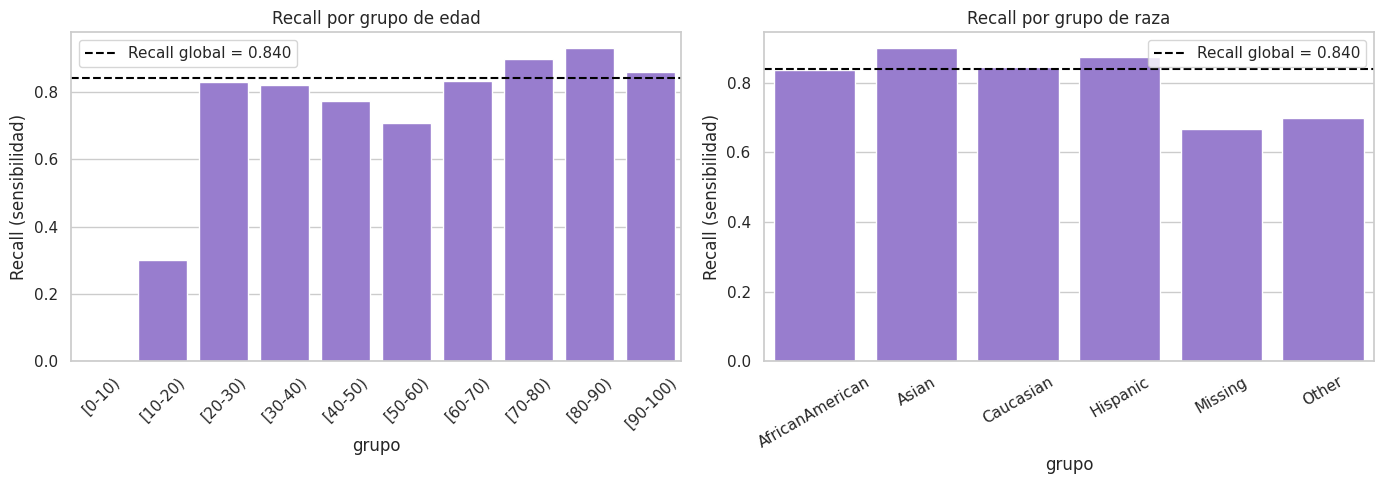

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fdf, title, rot in [
    (axes[0], fairness_age, "Recall por grupo de edad", 45),
    (axes[1], fairness_race, "Recall por grupo de raza", 30),
]:
    sns.barplot(data=fdf, x="grupo", y="recall", ax=ax, color="mediumpurple")
    overall_recall = recall_score(y_test, y_pred_test_tuned)
    ax.axhline(overall_recall, linestyle="--", color="black",
               label=f"Recall global = {overall_recall:.3f}")
    ax.set_title(title)
    ax.set_ylabel("Recall (sensibilidad)")
    ax.tick_params(axis="x", rotation=rot)
    ax.legend()

plt.tight_layout()
plt.show()

**Interpretación.** El *recall* global del modelo (con el umbral ajustado de la Sección 8) es de **0.84** para la clase de reingreso prematuro. Al desagregar por **edad**, el grupo `[0-10)` no tiene ningún caso real de reingreso `<30 días` en el conjunto de prueba (35 observaciones, 0% de tasa base), por lo que su precisión y recall de 0.000 no reflejan una falla del modelo, sino la ausencia de positivos contra los cuales medir — es un caso donde la métrica simplemente no es informativa, no donde hay evidencia de sesgo. El resto de los grupos de edad adultos (`[20-30)` en adelante) muestran recall consistentemente alto y creciente con la edad, lo cual es clínicamente razonable: a mayor edad, mayor probabilidad de que el historial de hospitalizaciones (la señal más fuerte del modelo) sea más extenso y por tanto más fácil de detectar.

Al desagregar por **raza**, los grupos con tamaño de muestra suficiente (`Caucasian`, `AfricanAmerican`, `Hispanic`, `Asian`) muestran recall entre 0.84 y 0.90 — sin diferencias preocupantes frente al recall global. Sin embargo, el grupo `Other` (304 observaciones) muestra un recall de **0.70**, y el grupo `Missing` de raza (475 observaciones, pacientes sin dato de raza registrado) muestra un recall de **0.667** — ambos notablemente por debajo del 0.84 global. Esto es un hallazgo que merece documentarse explícitamente en el Reporte Ejecutivo: el modelo está dejando pasar proporcionalmente más reingresos reales en estos dos grupos que en la población general. Antes de atribuirlo a un sesgo del algoritmo, vale la pena notar que ambos son los grupos con menor tamaño de muestra entre los que sí superan el umbral de 30 observaciones, por lo que su estimación de recall es menos estable — pero el patrón es lo bastante consistente (dos grupos distintos, ambos por debajo) como para que no deba descartarse sin un análisis adicional con más datos o técnicas de re-muestreo específicas por grupo.